# Study A: a stable score over a shifting population

A model is trained on the younger Adult population (age ≤ 45) and served the
older one (age > 45).

Raw-input monitoring detects this shift at least as
decisively.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

from common import (
    BLUE,
    GREY,
    GRID,
    ORANGE,
    RED,
    FIGURES_DIR,
    PSI_ALERT,
    PSI_BUCKETS,
    PSI_EPSILON,
    PSI_WARN,
    adv_auc_ci,
    explain,
    fit_model,
    importance_change,
    load_study_split,
    numeric_encode,
    psi_bins,
    psi_ci,
    psi_comparison,
    raw_psi,
    save_study_a,
    shap_psi,
    sign_flips,
    split_half,
    use_paper_style,
)

use_paper_style()
FIGURES_DIR.mkdir(exist_ok=True)

## 1. Data and the deliberate shift

`age ≤ 45` is the training population; `age > 45` stands in for drifted
production traffic. The reference window is the held-out validation split.

In [2]:
split = load_study_split()

print(f"train      {len(split.X_tr):>7,}")
print(f"reference  {len(split.X_val):>7,}   (validation split, age <= 45)")
print(f"drifted    {len(split.X_old):>7,}   (age > 45)")

train       24,008
reference   10,290   (validation split, age <= 45)
drifted     14,544   (age > 45)


## 2. Model Performance

In [3]:
model = fit_model(split)

f1_ref = f1_score(split.y_val, model.predict(split.X_val))
f1_curr = f1_score(split.y_old, model.predict(split.X_old))
print(f"F1 reference {f1_ref:.4f}\nF1 drifted   {f1_curr:.4f}")

F1 reference 0.7097
F1 drifted   0.7213


## 3. Attributions

In [4]:
s_ref, s_curr = explain(model, split.X_val), explain(model, split.X_old)

# No-drift control: the reference window split in half.
ctrl_a, ctrl_b = split_half(split.X_val)
s_ctrl_a, s_ctrl_b = split_half(s_ref)
s_ref.shape, s_curr.shape

((10290, 14), (14544, 14))

## 4. Adversarial validation on attributions and raw inputs


In [5]:
adv = {
    "shap_control": adv_auc_ci(s_ctrl_a, s_ctrl_b),
    "shap_drift": adv_auc_ci(s_ref, s_curr),
    "raw_control": adv_auc_ci(numeric_encode(ctrl_a), numeric_encode(ctrl_b)),
    "raw_drift": adv_auc_ci(numeric_encode(split.X_val), numeric_encode(split.X_old)),
}
for name, interval in adv.items():
    print(f"{name:<14} {interval['point']:.3f}  [{interval['lo']:.3f}, {interval['hi']:.3f}]")

shap_control   0.499  [0.489, 0.512]
shap_drift     0.967  [0.965, 0.971]
raw_control    0.500  [0.490, 0.509]
raw_drift      1.000  [1.000, 1.000]


## 5. Per-feature PSI

The aggregate picture hides a systematic divergence. On some features the input
distribution is quiet while the attributions are not.

In [6]:
attribution_psi = shap_psi(s_ref, s_curr)
input_psi = raw_psi(split.X_val, split.X_old)

psi_comparison(attribution_psi, input_psi).round(4)

,shap_psi,raw_psi,ratio
capital-gain,0.0732,0.0000,7.315036e+10
capital-loss,0.1763,0.0000,3.727192e+05
race,0.7519,0.0082,9.140210e+01
hours-per-week,0.1185,0.0082,1.437700e+01
native-country,0.4258,0.0376,1.133250e+01
sex,0.0492,0.0103,4.785200e+00
workclass,0.4314,0.1297,3.325000e+00
education-num,0.1665,0.0854,1.949000e+00
education,0.1095,0.1420,7.707000e-01
occupation,0.0454,0.0600,7.562000e-01


In [7]:
control_psi = shap_psi(s_ctrl_a, s_ctrl_b)
print(f"largest attribution PSI in the no-drift control: {control_psi.max():.4f}")

largest attribution PSI in the no-drift control: 0.0079


## 6. Attribution-space vs input-space drift

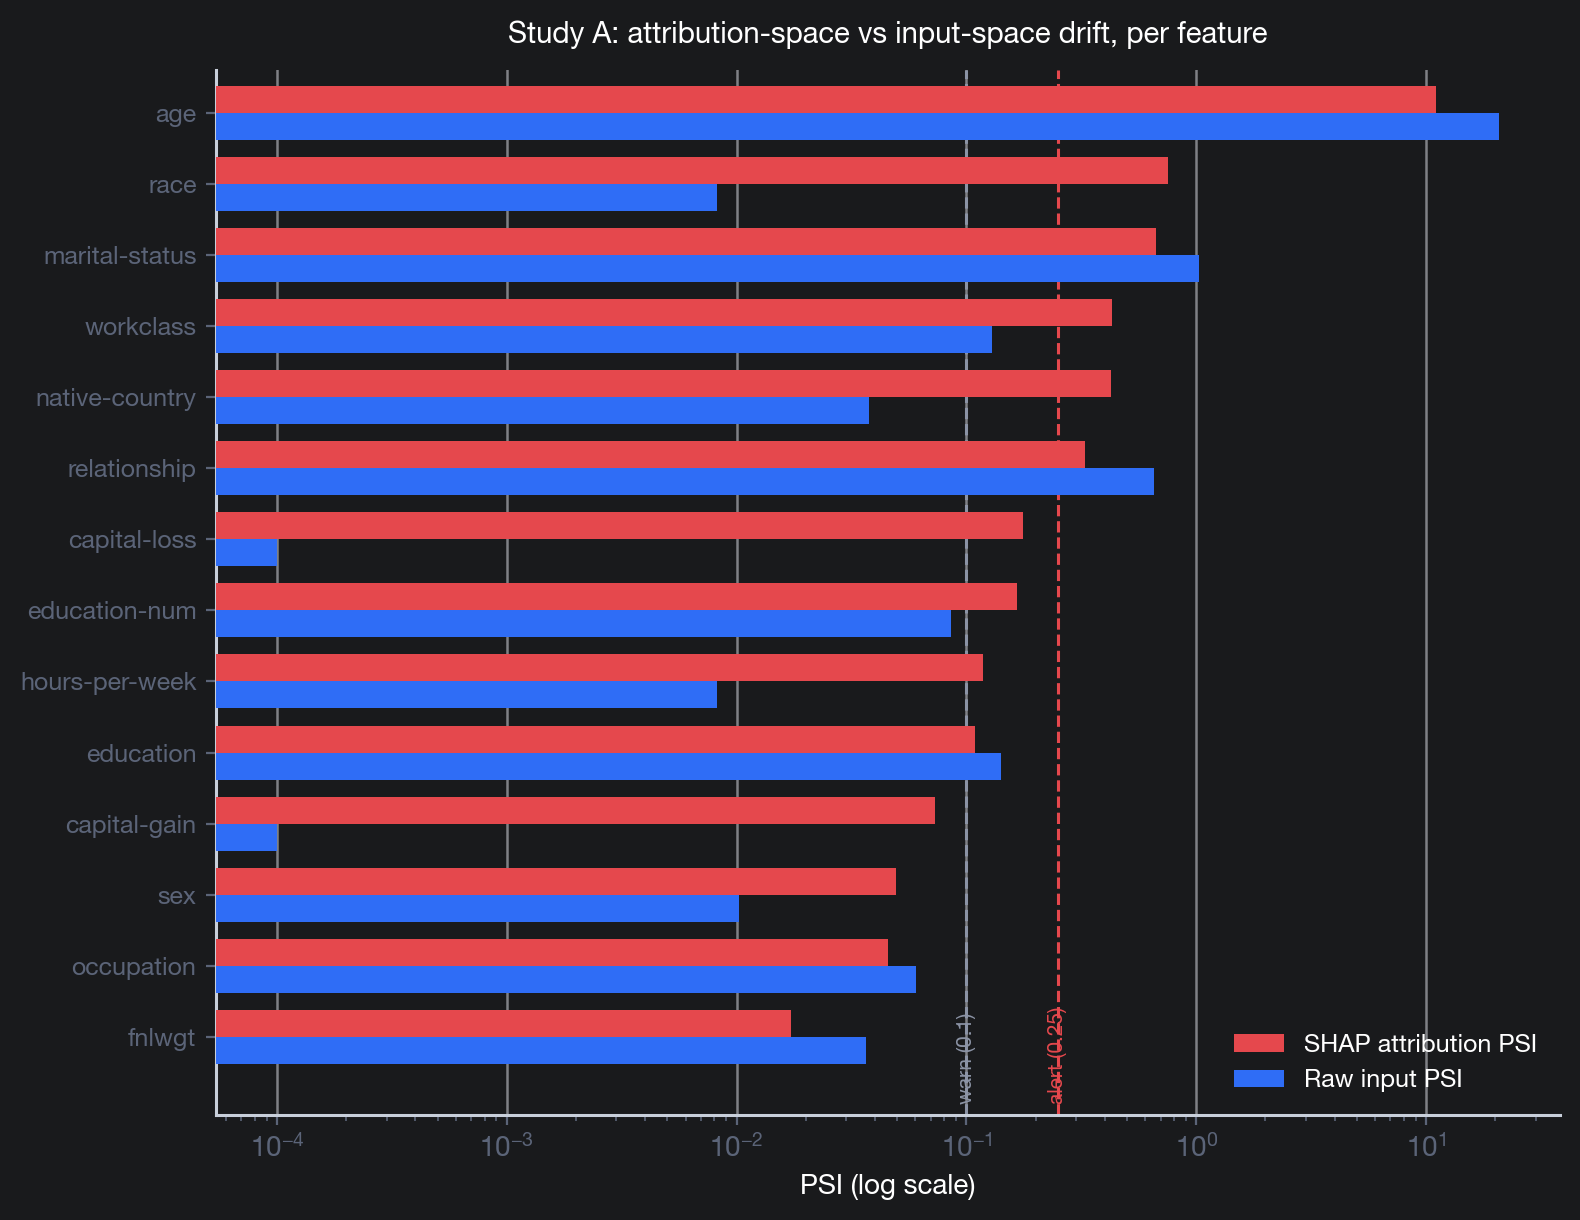

In [9]:
LOG_FLOOR = 1e-4

ranked = attribution_psi.sort_values()
paired_input_psi = input_psi.reindex(ranked.index)
positions, bar_h = np.arange(len(ranked)), 0.38

fig, ax = plt.subplots(figsize=(8.0, 6.2))
ax.barh(
    positions + bar_h / 2,
    ranked.clip(lower=LOG_FLOOR),
    bar_h,
    color=RED,
    label="SHAP attribution PSI",
    zorder=3,
)
ax.barh(
    positions - bar_h / 2,
    paired_input_psi.clip(lower=LOG_FLOOR),
    bar_h,
    color=BLUE,
    label="Raw input PSI",
    zorder=3,
)
ax.set_xscale("log")

for threshold, label, color in (
    (PSI_WARN, f"warn ({PSI_WARN})", GREY),
    (PSI_ALERT, f"alert ({PSI_ALERT})", RED),
):
    ax.axvline(threshold, ls="--", lw=1.1, color=color, zorder=2)
    ax.text(
        threshold, -0.95, label, rotation=90, fontsize=7.5, color=color, ha="center", va="bottom"
    )

ax.set_ylim(-1.1, len(ranked) - 0.4)
ax.set_yticks(positions)
ax.set_yticklabels(ranked.index, fontsize=9)
ax.set_xlabel("PSI (log scale)")
ax.grid(axis="x", color=GRID, lw=0.9, zorder=0)
ax.legend(fontsize=9, frameon=False, loc="lower right")
ax.set_title("Study A: attribution-space vs input-space drift, per feature", fontsize=10.5, pad=10)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure2.png", bbox_inches="tight")
plt.show()

## 7. Why the `age` PSI of 11 is a saturation flag, not a magnitude

`shap-monitor` bins the *reference* into ten quantile bins, so the reference
proportion cannot approach zero. The instability is on the other side of the
ratio: when the current distribution collapses, reference bins receive no mass at
all and must be floored at some epsilon. The reported value is then a direct
function of that constant.

In [10]:
age_ci = psi_ci(s_ref["age"], s_curr["age"])
print(f"age attribution PSI {age_ci['point']:.2f} [{age_ci['lo']:.2f}, {age_ci['hi']:.2f}]")
print(f"age raw input   PSI {input_psi['age']:.2f}\n")

age_bins = psi_bins(s_ref["age"], s_curr["age"])
terms = age_bins.terms()
print(f"{age_bins.empty.sum()} of {PSI_BUCKETS} reference bins receive no drifted mass")
print(f"they contribute {terms[age_bins.empty].sum() / terms.sum():.0%} of the total PSI\n")

print("epsilon sensitivity (same data, different floor):")
for eps in (PSI_EPSILON, 1e-6, 1e-4, 1e-3):
    print(f"  eps={eps:<8g} PSI={age_bins.terms(eps).sum():.2f}")

age attribution PSI 11.07 [10.90, 12.49]
age raw input   PSI 20.74

4 of 10 reference bins receive no drifted mass
they contribute 75% of the total PSI

epsilon sensitivity (same data, different floor):
  eps=1e-10    PSI=11.07
  eps=1e-06    PSI=7.39
  eps=0.0001   PSI=5.54
  eps=0.001    PSI=4.61


## 8. Age distribution and PSI binning

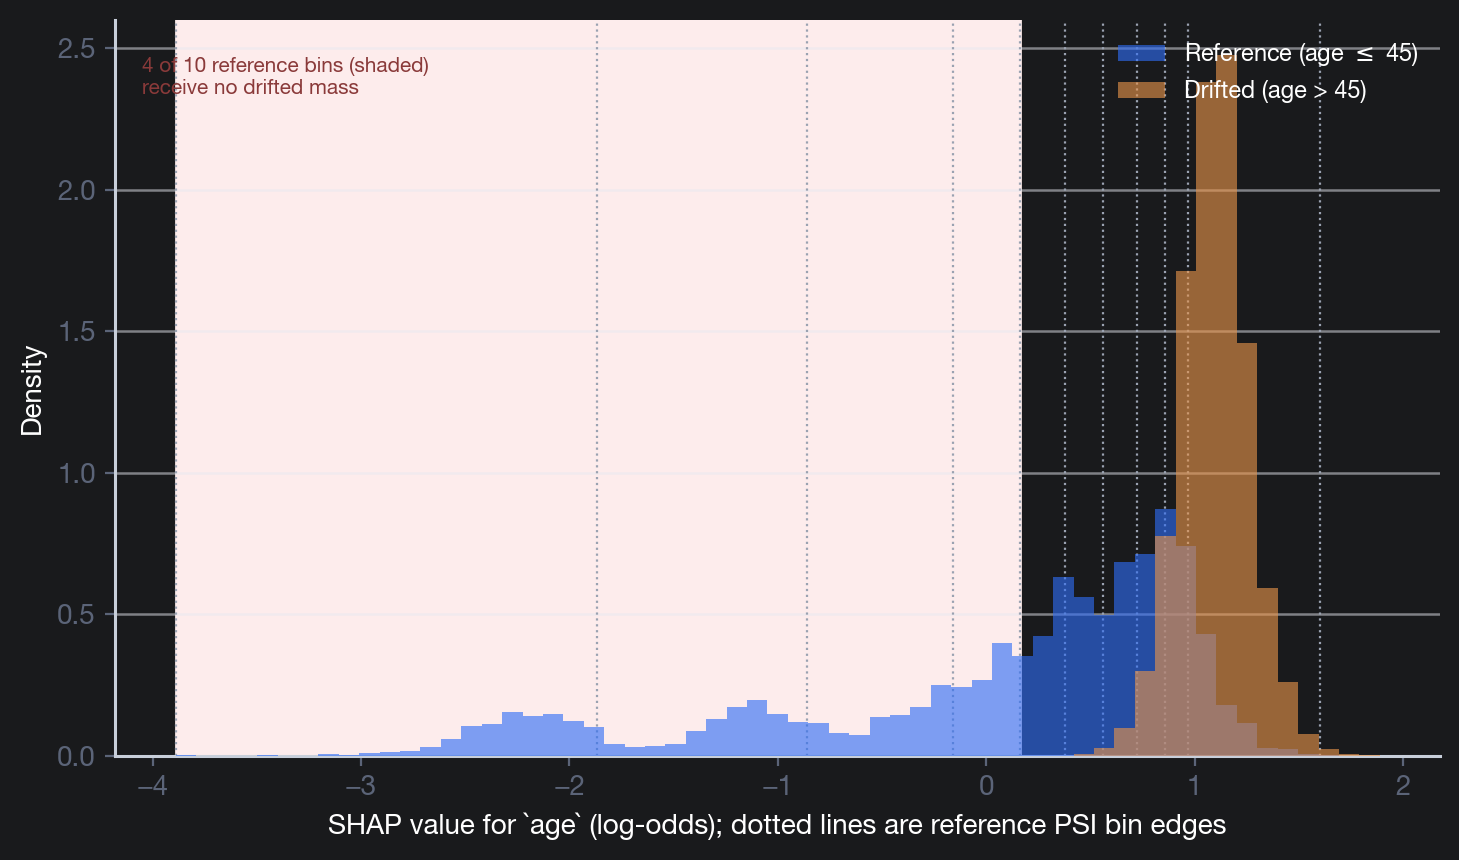

In [14]:
ref_age, curr_age, edges, empty = (
    age_bins.ref_values,
    age_bins.curr_values,
    age_bins.edges,
    age_bins.empty,
)

fig, ax = plt.subplots(figsize=(7.4, 4.4))
for i in np.flatnonzero(empty):
    ax.axvspan(edges[i], edges[i + 1], color="#fdecec", zorder=1)

bins = np.linspace(min(ref_age.min(), curr_age.min()), max(ref_age.max(), curr_age.max()), 60)
ax.hist(
    ref_age,
    bins=bins,
    alpha=0.62,
    color=BLUE,
    density=True,
    zorder=3,
    label="Reference (age $\\leq$ 45)",
)
ax.hist(
    curr_age,
    bins=bins,
    alpha=0.62,
    color=ORANGE,
    density=True,
    zorder=3,
    label="Drifted (age > 45)",
)
for edge in edges:
    ax.axvline(edge, ls=":", lw=0.8, color="#9aa2b1", zorder=2)

ax.annotate(
    f"{int(empty.sum())} of {PSI_BUCKETS} reference bins (shaded)\nreceive no drifted mass",
    xy=(0.02, 0.95),
    xycoords="axes fraction",
    va="top",
    fontsize=7.5,
    color="#8a3a3a",
)
ax.set_xlabel("SHAP value for `age` (log-odds); dotted lines are reference PSI bin edges")
ax.set_ylabel("Density")
ax.grid(axis="y", color=GRID, lw=0.9, zorder=0)
ax.legend(fontsize=8.5, frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure3.png", bbox_inches="tight")

## 9. Magnitude and sign changes

In [15]:
pct_change = importance_change(s_ref, s_curr)
flips = sign_flips(s_ref, s_curr)

print("largest changes in mean |SHAP|:")
print(pct_change.head(5).round(1).to_string())
print(f"\nsign flips ({len(flips)}): {flips}")

largest changes in mean |SHAP|:
workclass        82.0
capital-gain     50.9
capital-loss     42.9
age              33.3
education-num    29.3

sign flips (6): ['workclass', 'fnlwgt', 'marital-status', 'capital-gain', 'capital-loss', 'native-country']


## 10. Shared results

This plot needs both studies, so it is built at the end of notebook 02.
Study A's numbers are cached here for it.

In [16]:
save_study_a(
    f1_ref=f1_ref,
    f1_curr=f1_curr,
    adversarial=adv,
    attribution_psi=attribution_psi,
    input_psi=input_psi,
    age_psi_ci=age_ci,
    n_ref=len(split.X_val),
    n_curr=len(split.X_old),
)